1. make binary value become continued value
2. better understand the relationship btw signal and return

### get data

In [33]:
### get data
import time
import pandas as pd
import numpy as np
import talib.abstract as ta
import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# get klines from start to present
def get_history(symbol, interval, start= None, limit = 1000):
	if start:
		start = exchange.parse8601(start)

	data = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=start, limit=limit) 
	lastBarActual = data[-1][0] # timestamp of last loaded bar
	# timestamp of current bar
	lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]
	# if lastBarActual != lastBarCurrent => pull the next 1000 bars
	while lastBarActual != lastBarCurrent:
		time.sleep(0.1)
		data += exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=lastBarActual, limit=limit)[1:]
		lastBarActual = data[-1][0]
		lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]

	df = pd.DataFrame(data)
	df.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
	df.date= pd.to_datetime(df.date, unit='ms')
	df.set_index('date', inplace=True)
	
	return df


In [34]:
df = get_history("ETHUSDT", '4h', start='2023-01-01T00:00:00Z')
price_columns = ['open', 'high', 'low', 'close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()

In [37]:
df.tail(100)

,open,high,low,close,volume
date,,,,,
2025-10-16 16:00:00,3905.03,3966.29,3850.00,3865.97,1611881.582
2025-10-16 20:00:00,3865.97,3896.25,3822.50,3892.02,536855.936
2025-10-17 00:00:00,3892.02,3948.06,3886.15,3931.44,461138.681
2025-10-17 04:00:00,3931.45,3934.73,3751.00,3754.79,1224800.637
2025-10-17 08:00:00,3754.78,3817.40,3671.00,3776.30,2181211.218
...,...,...,...,...,...
2025-11-01 12:00:00,3876.08,3901.36,3855.66,3893.01,302448.751
2025-11-01 16:00:00,3893.02,3907.61,3860.44,3878.34,281895.016
2025-11-01 20:00:00,3878.33,3890.00,3862.44,3872.14,108247.150


### build factor

In [38]:
df['ma_21'] = ta.MA(df.close, 21)

In [40]:
bias_ratio = df.close/df.ma_21

<Axes: >

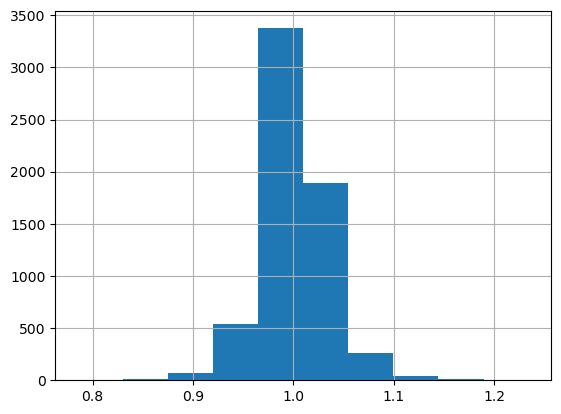

In [43]:
bias_ratio.hist()
# 1. all factor value is positive
# 2. close to 正态分布
# 3. some value lay in area of tail

In [53]:
# 未来收益率, 用于评估因子与未来收益率的相关性情况
# label(衡量因子的标准的定义): 1. ret_n 2. volatility_n 3. 
def calc_forward_return(df, n=1):
    return df['close'].shift(-n) / df['close'] - 1

df['ret_1'] = calc_forward_return(df, 1)
df['ret_8'] = calc_forward_return(df, 8)


In [ ]:
# task1: corr: {线性相关: Pearson, 单调相关:Spearman}
# TODO: 研究两种相关性系数的计算方法与含义
# TODO: 计算相关性的时候, 会用到全局的均值,
# TODO: 熟悉线性模型的假设
ic_ret_1 = df.ma_21.corr(df.ret_1, method='spearman')
ic_ret_13 = df.ma_21.corr(df.ret_13, method='spearman')
print(f'和1个周期之后的收益率相关性为{ic_ret_1}')
print(f'和13个周期之后的收益率相关性为{ic_ret_13}')

和1个周期之后的收益率相关性is-0.013696018915684767
和13个周期之后的收益率相关性is-0.07115011758249573


C:\Users\xlfin\AppData\Local\Temp\ipykernel_18752\1771118948.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_by_bin = df_tmp.groupby('bin').apply(


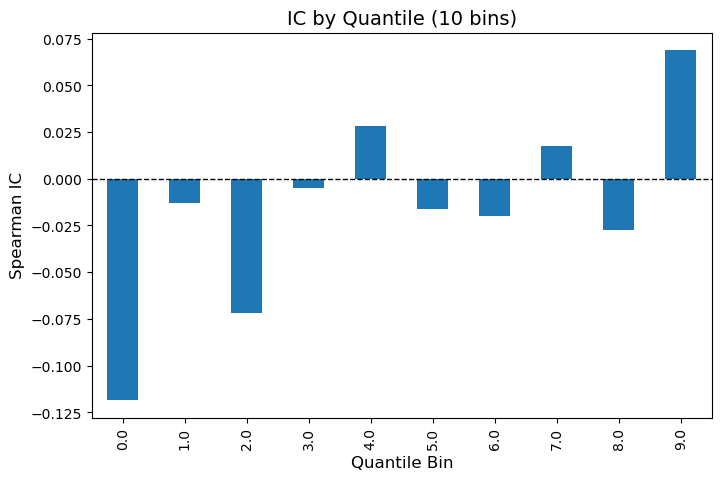

In [49]:
# 分箱处理( 等分位数分箱) 
# 探究因子在哪个范围与label的相关性最高(有更好的预测能力)
bins = pd.qcut(bias_ratio, q=10, labels=False, duplicates='drop')
# create a df 方便操作
df_tmp = pd.DataFrame({
    'bias_ratio': bias_ratio,
    'ret_13': df['ret_13'],
    'bin': bins
})

ic_by_bin = df_tmp.groupby('bin').apply(
    lambda g:g['bias_ratio'].corr(g['ret_13'], method='spearman')
)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
ic_by_bin.plot(kind='bar')

plt.title('IC by Quantile (10 bins)', fontsize=14)
plt.xlabel('Quantile Bin', fontsize=12)
plt.ylabel('Spearman IC', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.show()